In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

warnings.filterwarnings('ignore')

os.makedirs('../data/model_outputs', exist_ok=True)

df = pd.read_csv('../data/csv/combined_dataset.csv', low_memory=False)

df.columns = df.columns.str.strip()

df['Label'] = df['Label'].astype(str).str.strip()
df['Label'] = df['Label'].replace({
    'Web Attack � Brute Force': 'Web Attack - Brute Force',
    'Web Attack � XSS': 'Web Attack - XSS',
    'Web Attack � Sql Injection': 'Web Attack - Sql Injection'
})

# Inf / NaN temizliği
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# Tamamen sıfır olan numeric feature'ları çıkar
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cols_to_drop = [col for col in numeric_cols if (df[col] == 0).all()]
df.drop(columns=cols_to_drop, inplace=True)

# Çok küçük sınıfları çıkar
rare_classes = ['Heartbleed', 'Web Attack - Sql Injection', 'Infiltration']
df = df[~df['Label'].isin(rare_classes)].copy()

print(f"✓ Dataset hazır: {df.shape[0]:,} satır, {df.shape[1]} sütun")
print("\nLabel dağılımı:")
print(df['Label'].value_counts())

print("\nsource_file dağılımı:")
print(df['source_file'].value_counts())

✓ Dataset hazır: 1,099,957 satır, 72 sütun

Label dağılımı:
Label
BENIGN                      543469
DoS Hulk                    230124
PortScan                    158804
DDoS                        128025
DoS GoldenEye                10293
FTP-Patator                   7935
SSH-Patator                   5897
DoS slowloris                 5796
DoS Slowhttptest              5499
Bot                           1956
Web Attack - Brute Force      1507
Web Attack - XSS               652
Name: count, dtype: int64

source_file dağılımı:
source_file
Monday-WorkingHours.pcap_ISCX.csv                              529481
Wednesday-workingHours.pcap_ISCX.csv                           253712
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv           160801
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv               130025
Tuesday-WorkingHours.pcap_ISCX.csv                              15831
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv           4157
Friday-WorkingHours-Morning.pcap_

Train boyutu: (799024, 68)
Test boyutu: (300933, 68)

Train label dağılımı:
Label
0    533480
1    265544
Name: count, dtype: int64

Test label dağılımı:
Label
1    290944
0      9989
Name: count, dtype: int64

Çıkarılan feature'lar:
['Flow Bytes/s', 'Flow Packets/s']

Accuracy: 0.3095572768689376

Classification Report:
              precision    recall  f1-score   support

           0       0.05      1.00      0.09      9989
           1       1.00      0.29      0.44    290944

    accuracy                           0.31    300933
   macro avg       0.52      0.64      0.27    300933
weighted avg       0.97      0.31      0.43    300933



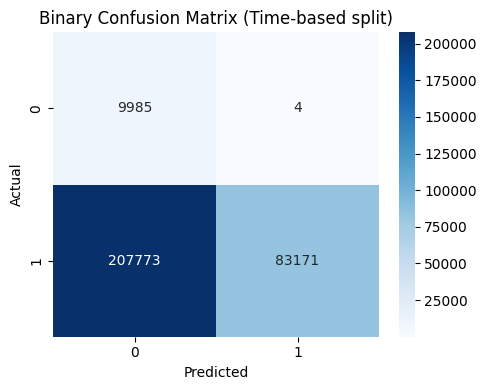

In [2]:
# Binary label oluştur: 0 = BENIGN, 1 = ATTACK
df_binary = df.copy()
df_binary['Label'] = df_binary['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

# Leakage riski olan bazı rate feature'ları çıkar
drop_features = ['Flow Bytes/s', 'Flow Packets/s']
existing_drop_features = [col for col in drop_features if col in df_binary.columns]

# Time-based split: Monday/Tuesday/Wednesday = train, Thursday/Friday = test
train_patterns = ['Monday', 'Tuesday', 'Wednesday']
test_patterns = ['Thursday', 'Friday']

train_mask = df_binary['source_file'].str.contains('|'.join(train_patterns), case=False, na=False)
test_mask = df_binary['source_file'].str.contains('|'.join(test_patterns), case=False, na=False)

train_df = df_binary[train_mask].copy()
test_df = df_binary[test_mask].copy()

# source_file artık feature olmayacak
X_train = train_df.drop(columns=['Label', 'source_file'] + existing_drop_features)
y_train = train_df['Label']

X_test = test_df.drop(columns=['Label', 'source_file'] + existing_drop_features)
y_test = test_df['Label']

print("Train boyutu:", X_train.shape)
print("Test boyutu:", X_test.shape)

print("\nTrain label dağılımı:")
print(y_train.value_counts())

print("\nTest label dağılımı:")
print(y_test.value_counts())

print("\nÇıkarılan feature'lar:")
print(existing_drop_features)

# Model
model_binary = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model_binary.fit(X_train, y_train)

# Tahmin
y_pred = model_binary.predict(X_test)

# Sonuçlar
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Binary Confusion Matrix (Time-based split)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()